# Homework 5 - LLaVA-7B Fine-Tuning



Fine-tune LLaVA on 20 image–instruction pairs using LoRA.


- Runtime: A100 GPU



---
**Notebook Sections:**
1. Environment Setup
2. Prepare Data
3. Run LoRA Fine-Tuning
5. Inference with Fine-Tuned Model
6. Save to HuggingFace Hub
7. B2 - Sample Set Finetune
  *   Get the testbench data
  *   Run extra epoch on sample set
  *   Generate answers on LLaVA-Bench-in-the-Wild
  *   LLaVA-Bench scores




## Check GPU

In [2]:
!nvidia-smi
# You should see A100 with ~40GB memory
# If you see T4 or less, go to Runtime > Change runtime type and select A100

Tue Mar 17 17:59:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Install Dependencies



In [3]:
import os

# Clone LLaVA repository
if not os.path.exists('LLaVA'):
    !git clone https://github.com/haotian-liu/LLaVA.git

%cd LLaVA

# Install LLaVA and dependencies\n",
!pip install -e . -q
!pip install peft==0.9.0 -q
!pip install bitsandbytes==0.43.0 -q
!pip install transformers==4.37.2 -q
!pip install accelerate==0.27.2 -q
!pip install deepspeed==0.13.1 -q
!pip install einops -q
# !pip install flash-attn --no-build-isolation -q


Cloning into 'LLaVA'...
remote: Enumerating objects: 2297, done.
remote: Total 2297 (delta 0), reused 0 (delta 0), pack-reused 2297 (from 1)
Receiving objects: 100% (2297/2297), 13.71 MiB | 7.76 MiB/s, done.
Resolving deltas: 100% (1404/1404), done.
/content/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from llava) (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 MB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━

In [4]:
# Install a version compatible with PyTorch 2.x
!pip install deepspeed==0.15.4

# Verify it loads correctly
import deepspeed
print(f"DeepSpeed version: {deepspeed.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for deepspeed: filename=deepspeed-0.15.4-py3-none-any.whl size=1527837 sha256=7530e806ab66e90845309b68c4efa681ee49b5692f8b86035e0aac494416654d
  Stored in directory: /root/.cache/pip/wheels/15/a6/c9/52b7ecb4a784659488b6811379f0f4d3820a656e7307afbec9
Successfully built deepspeed
  Attempting uninstall: deepspeed
    Found existing installation: deepspeed 0.13.1
    Uninstalling deepspeed-0.13.1:
      Successfully uninstalled deepspeed-0.13.1
[2026-03-17 18:01:29,782] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)
DeepSpeed version: 0.15.4


In [5]:
!pip install bitsandbytes --upgrade -q

# Verify
import bitsandbytes as bnb
print(f"bitsandbytes version: {bnb.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00
bitsandbytes version: 0.49.2


In [6]:
!pip install transformers==4.37.2 -q

# Verify
import transformers
print(f"transformers version: {transformers.__version__}")

transformers version: 4.37.2


In [7]:
%cd /content/LLaVA

# Install LLaVA but skip the torch dependency
!pip install -e . --no-deps -q

# Install everything else LLaVA needs
!pip install transformers==4.37.2 tokenizers accelerate peft einops \
             sentencepiece protobuf pillow requests tqdm -q

# Verify
import torch
print(f"PyTorch version: {torch.__version__}")

import llava
print(f"LLaVA found: {llava.__file__}")

/content/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for llava (pyproject.toml) ... done
PyTorch version: 2.10.0+cu128
LLaVA found: /content/LLaVA/llava/__init__.py


In [8]:
with open('/content/LLaVA/llava/train/train_mem.py', 'w') as f:
    f.write('''from llava.train.train import train

train(attn_implementation="eager")
''')

# Verify
with open('/content/LLaVA/llava/train/train_mem.py', 'r') as f:
    print(f.read())

from llava.train.train import train

train(attn_implementation="eager")



## Prepare Data

In [13]:
import os
import shutil

directory_to_clear = '/content/drive/MyDrive/TCSS590/Llava/data/'

if os.path.exists(directory_to_clear):
    print(f"Deleting contents of {directory_to_clear}...")
    shutil.rmtree(directory_to_clear)
    print(f"Contents of {directory_to_clear} deleted.")

os.makedirs(directory_to_clear, exist_ok=True)
print(f"Recreated empty directory: {directory_to_clear}")

Deleting contents of /content/drive/MyDrive/TCSS590/Llava/data/...
Contents of /content/drive/MyDrive/TCSS590/Llava/data/ deleted.
Recreated empty directory: /content/drive/MyDrive/TCSS590/Llava/data/


In [ ]:
"""
======================
Download 20 handwriting images from IAM (Teklia/IAM-line on HuggingFace)
and format them into LLaVA-ready JSON for fine-tuning


Output:
    data/my_dataset/images/
    data/my_dataset/train.json
"""

import os
import json
from datasets import load_dataset
from PIL import Image

# ─── Config ───────────────────────────────────────────────────────────────────
NUM_SAMPLES = 20
IMAGE_DIR     = "/content/drive/MyDrive/TCSS590/Llava/data/images"
OUTPUT_JSON   = "/content/drive/MyDrive/TCSS590/Llava/data/train.json"
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(IMAGE_DIR, exist_ok=True)

print("Loading IAM Handwriting dataset from HuggingFace...")

# Teklia/IAM-line: each sample has:
#   - image      : PIL Image of a handwritten line
#   - text       : the ground truth transcription of that line
ds = load_dataset(
    "Teklia/IAM-line",
    split="train",
    streaming=True
)

# ── Instruction templates ──────────────────────────────────────────────────────
INSTRUCTION_TEMPLATES = [
    "Transcribe the handwritten text in this image.",
    "What does the handwriting in this image say?",
    "Read and transcribe the text shown in this handwritten line.",
    "What is written in this image? Please transcribe it exactly.",
    "Can you read the handwritten text in this image and write it out?",
]

llava_data = []

print(f"Downloading {NUM_SAMPLES} handwriting images...\n")

for i, sample in enumerate(ds.take(NUM_SAMPLES)):

    # ── Save image ─────────────────────────────────────────────────────────
    image: Image.Image = sample["image"].convert("RGB")
    image_filename = f"iam_{i:03d}.jpg"
    image_path = os.path.join(IMAGE_DIR, image_filename)
    image.save(image_path, "JPEG", quality=95)

    # ── Get ground truth transcription ────────────────────────────────────
    transcription = sample["text"].strip()

    # ── Pick instruction template (cycle through them) ─────────────────────
    instruction = INSTRUCTION_TEMPLATES[i % len(INSTRUCTION_TEMPLATES)]

    # ── Format into LLaVA conversation structure ───────────────────────────
    entry = {
        "id": f"iam_{i:03d}",
        "image": image_filename,
        "conversations": [
            {
                "from": "human",
                "value": f"<image>\n{instruction}"
            },
            {
                "from": "gpt",
                "value": transcription
            }
        ]
    }

    llava_data.append(entry)

    print(f"  [{i+1:02d}/{NUM_SAMPLES}] {image_filename}")
    print(f"          Q: {instruction}")
    print(f"          A: {transcription[:80]}{'...' if len(transcription) > 80 else ''}\n")

# ── Save JSON ──────────────────────────────────────────────────────────────────
with open(OUTPUT_JSON, "w") as f:
    json.dump(llava_data, f, indent=2)

print("─" * 60)
print(f"Images saved to : {IMAGE_DIR}/")
print(f"JSON saved to   : {OUTPUT_JSON}")
print(f"Total samples   : {len(llava_data)}")
print("─" * 60)

# ── Preview the JSON ───────────────────────────────────────────────────────────
print("\nPreview of train.json (first 2 entries):\n")
print(json.dumps(llava_data[:2], indent=2))

# ── Quick validation ───────────────────────────────────────────────────────────
print("\nValidating all images exist...")
missing = []
for item in llava_data:
    path = os.path.join(IMAGE_DIR, item["image"])
    if not os.path.exists(path):
        missing.append(item["image"])

if missing:
    print(f"Missing {len(missing)} images: {missing}")
else:
    print(f"All {len(llava_data)} images verified")

# ── Show image dimensions for sanity check ────────────────────────────────────
print("\nImage dimension check (first 5):")
for item in llava_data[:5]:
    path = os.path.join(IMAGE_DIR, item["image"])
    img = Image.open(path)
    print(f"   {item['image']}: {img.size[0]}x{img.size[1]} px")

Loading IAM Handwriting dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]


  [01/20] iam_000.jpg
          Q: Transcribe the handwritten text in this image.
          A: put down a resolution on the subject

  [02/20] iam_001.jpg
          Q: What does the handwriting in this image say?
          A: and he is to be backed by Mr. Will

  [03/20] iam_002.jpg
          Q: Read and transcribe the text shown in this handwritten line.
          A: nominating any more Labour life Peers

  [04/20] iam_003.jpg
          Q: What is written in this image? Please transcribe it exactly.
          A: M Ps tomorrow. Mr. Michael Foot has

  [05/20] iam_004.jpg
          Q: Can you read the handwritten text in this image and write it out?
          A: Griffiths, M P for Manchester Exchange .

  [06/20] iam_005.jpg
          Q: Transcribe the handwritten text in this image.
          A: is to be made at a meeting of Labour

  [07/20] iam_006.jpg
          Q: What does the handwriting in this image say?
          A: A MOVE to stop Mr. Gaitskell from

  [08/20] iam_007.jpg
    

## Run LoRA Fine-Tuning


- Download LLaVA-1.5-7b
- Fine-tune with LoRA on 20 samples



In [ ]:
!deepspeed /content/LLaVA/llava/train/train_mem.py \
    --lora_enable True \
    --lora_r 128 \
    --lora_alpha 256 \
    --deepspeed /content/LLaVA/scripts/zero2.json \
    --model_name_or_path liuhaotian/llava-v1.5-7b \
    --version v1 \
    --data_path /content/drive/MyDrive/TCSS590/Llava/data/train.json \
    --image_folder /content/drive/MyDrive/TCSS590/Llava/data/images \
    --vision_tower openai/clip-vit-large-patch14-336 \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --image_aspect_ratio pad \
    --bf16 True \
    --bits 16 \
    --output_dir /content/LLaVA/checkpoints/llava-lora-experiment \
    --num_train_epochs 10 \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 1 \
    --evaluation_strategy no \
    --save_strategy steps \
    --save_steps 50 \
    --save_total_limit 1 \
    --learning_rate 2e-4 \
    --weight_decay 0.0 \
    --warmup_ratio 0.03 \
    --lr_scheduler_type cosine \
    --logging_steps 1 \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --lazy_preprocess True \
    --report_to none

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[2026-03-12 04:44:23,399] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2026-03-12 04:44:26,888] [WARNING] [runner.py:215:fetch_hostfile] Unable to find hostfile, will proceed with training with local resources only.
[2026-03-12 04:44:26,889] [INFO] [runner.py:607:main] cmd = /usr/bin/python3 -u -m deepspeed.launcher.launch --world_info=eyJsb2NhbGhvc3QiOiBbMF19 --master_addr=127.0.0.1 --master_port=29500 --enable_each_rank_log=None /content/LLaVA/llava/train/train_mem.py --lora_enable True --lora_r 128 --lora_alpha 256 --deepspeed /content/LLaVA/scripts/zero2.json --model_name_or_path liuhaotian/llava-v1.5-7b --version v1 --da

## Run Inference with Fine-Tuned Model

Test the model on one of the sample image from the train dataset.

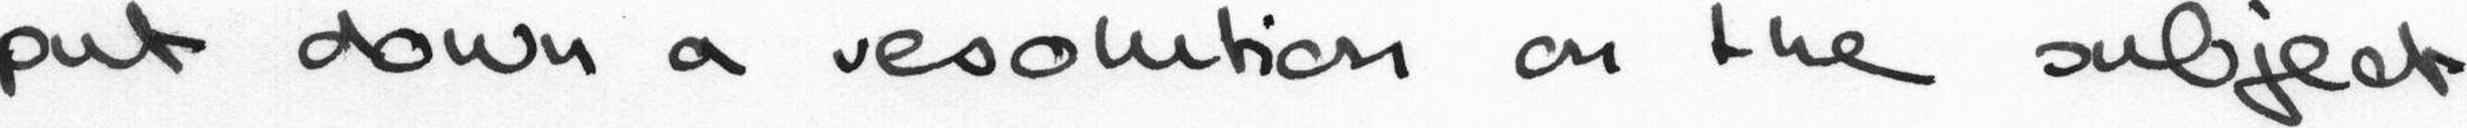

In [ ]:
from PIL import Image
from IPython.display import display

image_path = '/content/drive/MyDrive/TCSS590/Llava/data/images/iam_000.jpg'

try:
    image = Image.open(image_path)
    display(image)
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import torch
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path, process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.conversation import conv_templates
from PIL import Image
import copy

BASE_MODEL   = 'liuhaotian/llava-v1.5-7b'
LORA_WEIGHTS = '/content/LLaVA/checkpoints/llava-lora-experiment'

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=LORA_WEIGHTS,
    model_base=BASE_MODEL,
    model_name='llava-v1.5-7b-lora'
)

# Test on one of your training images
image = Image.open('/content/drive/MyDrive/TCSS590/Llava/data/images/iam_000.jpg').convert('RGB')
question = "Transcribe the handwritten text in this image."

image_tensor = process_images([image], image_processor, model.config)
image_tensor = image_tensor.to(model.device, dtype=torch.float16)

conv = copy.deepcopy(conv_templates['v1'])
conv.messages = list(conv.messages) # Convert tuple to list
conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + '\n' + question)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()

input_ids = tokenizer_image_token(
    prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
).unsqueeze(0).to(model.device)

with torch.inference_mode():
    output_ids = model.generate(
        input_ids,
        images=image_tensor,
        image_sizes=[image.size],
        do_sample=False,
        max_new_tokens=200
    )

response = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()
print(f"Response: {response}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading LLaVA from base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading additional LLaVA weights...
Loading LoRA weights...
Merging LoRA weights...
Model is loaded...
Response: put down a resolution on the subject


## Test the model on a new handwritten note sample

In [ ]:
# Upload a test image
from google.colab import files
print('Upload a test image to query fine-tuned model:')
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]
print(f'\nTest image: {test_image_path}')

Upload a test image to query your fine-tuned model:


Saving Handwriting_Test.png to Handwriting_Test.png

Test image: Handwriting_Test.png


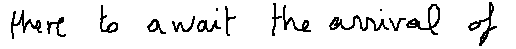

In [ ]:
from PIL import Image
from IPython.display import display

try:
    image = Image.open(test_image_path)
    display(image)
except FileNotFoundError:
    print(f"Error: Image not found at {test_image_path}")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import torch
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path, process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.conversation import conv_templates
from PIL import Image
import copy

# ─── Config ───────────────────────────────────────────────
BASE_MODEL   = 'liuhaotian/llava-v1.5-7b'
LORA_WEIGHTS = '/content/LLaVA/checkpoints/llava-lora-experiment'
YOUR_QUESTION = 'Describe what you see in this image.'
# ──────────────────────────────────────────────────────────

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=LORA_WEIGHTS,
    model_base=BASE_MODEL,
    model_name='llava-v1.5-7b-lora'
)

# Load and process image
image = Image.open(test_image_path).convert('RGB')
image_tensor = process_images([image], image_processor, model.config)
image_tensor = image_tensor.to(model.device, dtype=torch.float16)

# Build prompt
conv = copy.deepcopy(conv_templates['v1'])
conv.messages = list(conv.messages) # Convert tuple to list
conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + '\n' + YOUR_QUESTION)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()

input_ids = tokenizer_image_token(
    prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
).unsqueeze(0).to(model.device)

# Generate response
with torch.inference_mode():
    output_ids = model.generate(
        input_ids,
        images=image_tensor,
        image_sizes=[image.size],
        do_sample=False,
        temperature=0,
        max_new_tokens=512
    )

response = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()

print(f'\nQuestion: {YOUR_QUESTION}')
print(f'\nModel Response:\n{response}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading LLaVA from base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for model.mm_projector.0.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for model.mm_projector.0.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for model.mm_projector.2.weight: copying from a non-meta parameter in the checkpoint t

Loading additional LLaVA weights...
Loading LoRA weights...


Merging LoRA weights...
Model is loaded...


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:392: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



Question: Describe what you see in this image.

Model Response:
here to wait the arrival of


## Save LoRA Weights to Google Drive

In [ ]:
import shutil
src = '/content/LLaVA/checkpoints/llava-lora-experiment'
dst = '/content/drive/MyDrive/TCSS590/Llava/llava-lora-experiment'

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f'LoRA weights saved to Google Drive: {dst}')

LoRA weights saved to Google Drive: /content/drive/MyDrive/TCSS590/Llava/llava-lora-experiment


## Push to HuggingFace Hub

In [ ]:
# Login to HuggingFace
from huggingface_hub import login, HfApi
login()

# uggingFace username/repo-name
HF_REPO = 'VijayaVajjhala/llava-lora-experiment'

api = HfApi()
api.create_repo(HF_REPO, exist_ok=True)
api.upload_folder(
    folder_path='/content/LLaVA/checkpoints/llava-lora-experiment',
    repo_id=HF_REPO,
    repo_type='model'
)
print(f'Model pushed to: https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...heckpoint-50/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

  ...kpoint-50/tokenizer.model:  95%|#########4|  473kB /  500kB            

  ...eckpoint-50/rng_state.pth:  77%|#######7  | 11.4kB / 14.7kB            

...

  ...adapter_model.safetensors:   1%|          | 4.38MB /  640MB            

  ...p_rank_00_model_states.pt:   0%|          |  625kB /  682MB            

  ...oint-50/training_args.bin:   3%|3         |   218B / 6.67kB            

  ...t/non_lora_trainables.bin:   3%|3         | 1.37MB / 42.0MB            

Model pushed to: https://huggingface.co/VijayaVajjhala/llava-lora-experiment


## B2 - Sample Set Finetune

### Clear data directory

In [ ]:
import os
import shutil

folder_to_delete = '/content/drive/MyDrive/TCSS590/Llava/data/train2017'

if os.path.exists(folder_to_delete):
    print(f"Deleting folder: {folder_to_delete}...")
    shutil.rmtree(folder_to_delete)
    print(f"Folder '{folder_to_delete}' deleted successfully.")
else:
    print(f"Folder not found: {folder_to_delete}")

Deleting folder: /content/drive/MyDrive/TCSS590/Llava/data/train2017...
Folder '/content/drive/MyDrive/TCSS590/Llava/data/train2017' deleted successfully.


### Get the testbench data

In [14]:
import subprocess, os

# LLaVA's built-in sample instruction data
!wget https://huggingface.co/datasets/liuhaotian/LLaVA-Instruct-150K/resolve/main/llava_instruct_80k.json \
      -O /content/drive/MyDrive/TCSS590/Llava/data/llava_sample.json

# Download COCO train2017
print("Downloading COCO train2017.")
!wget -q http://images.cocodataset.org/zips/train2017.zip -O /content/train2017.zip

print("Unzipping to Google Drive...")
!unzip -q /content/train2017.zip -d /content/drive/MyDrive/TCSS590/Llava/data/

import os
count = len(os.listdir("/content/drive/MyDrive/TCSS590/Llava/data/train2017"))
print(f"Done — {count} images extracted")

--2026-03-17 18:08:57--  https://huggingface.co/datasets/liuhaotian/LLaVA-Instruct-150K/resolve/main/llava_instruct_80k.json
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.40, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/643dda8f317127fb1e30b27b/be684143b9dce181bf5243a6da0e299febdb36d2c70c35ff3160e7b13958f434?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27llava_instruct_80k.json%3B+filename%3D%22llava_instruct_80k.json%22%3B&response-content-type=application%2Fjson&Expires=1773774537&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzczNzc0NTM3fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjQzZGRhOGYzMTcxMjdmYjFlMzBiMjdiL2JlNjg0MTQzYjlkY2UxODFiZjUyNDNhNmRhMGUyOTlmZWJkYjM2ZDJjNzBjMzVmZjMxNjBlN2IxMzk1OGY0MzRcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0a

In [15]:
import json

with open('/content/drive/MyDrive/TCSS590/Llava/data/llava_sample.json') as f:
    data = json.load(f)

subset = data[:2500]   # take first 2,500 pairs

with open('/content/drive/MyDrive/TCSS590/Llava/data/llava_2500.json', 'w') as f:
    json.dump(subset, f)

print(f"Subset saved: {len(subset)} pairs")

Subset saved: 2500 pairs


### Run extra epoch on sample set

In [16]:
import os
os.makedirs("/content/drive/MyDrive/TCSS590/Llava/checkpoints/llava-lora-sample", exist_ok=True)
os.makedirs("/content/drive/MyDrive/TCSS590/Llava/logs", exist_ok=True)

!deepspeed /content/LLaVA/llava/train/train_mem.py \
    --lora_enable True \
    --lora_r 128 \
    --lora_alpha 256 \
    --deepspeed /content/LLaVA/scripts/zero2.json \
    --model_name_or_path liuhaotian/llava-v1.5-7b \
    --version v1 \
    --data_path /content/drive/MyDrive/TCSS590/Llava/data/llava_2500.json \
    --image_folder /content/drive/MyDrive/TCSS590/Llava/data/train2017 \
    --vision_tower openai/clip-vit-large-patch14-336 \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --image_aspect_ratio pad \
    --bf16 True \
    --bits 16 \
    --output_dir /content/drive/MyDrive/TCSS590/Llava/checkpoints/llava-lora-sample \
    --num_train_epochs 1 \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 4 \
    --evaluation_strategy no \
    --save_strategy steps \
    --save_steps 200 \
    --save_total_limit 3 \
    --learning_rate 2e-4 \
    --weight_decay 0.0 \
    --warmup_ratio 0.03 \
    --lr_scheduler_type cosine \
    --logging_steps 10 \
    --logging_dir /content/drive/MyDrive/TCSS590/Llava/logs \
    --report_to tensorboard \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --lazy_preprocess True \
    2>&1 | tee /content/drive/MyDrive/TCSS590/Llava/logs/train_log.txt

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[2026-03-17 19:00:37,327] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2026-03-17 19:00:40,955] [WARNING] [runner.py:215:fetch_hostfile] Unable to find hostfile, will proceed with training with local resources only.
[2026-03-17 19:00:40,956] [INFO] [runner.py:607:main] cmd = /usr/bin/python3 -u -m deepspeed.launcher.launch --world_info=eyJsb2NhbGhvc3QiOiBbMF19 --master_addr=127.0.0.1 --master_port=29500 --enable_each_rank_log=None /content/LLaVA/llava/train/train_mem.py --lora_enable True --lora_r 128 --lora_alpha 256 --deepspeed /content/LLaVA/scripts/zero2.json --model_name_or_path liuhaotian/llava-v1.5-7b --version v1 --da

In [18]:
# Check latest checkpoint exists
!ls -lh /content/drive/MyDrive/TCSS590/Llava/checkpoints/llava-lora-sample

total 651M
-rw------- 1 root root  700 Mar 17 19:28 adapter_config.json
-rw------- 1 root root 611M Mar 17 19:28 adapter_model.safetensors
-rw------- 1 root root 1.4K Mar 17 19:28 config.json
-rw------- 1 root root  41M Mar 17 19:28 non_lora_trainables.bin
-rw------- 1 root root 5.0K Mar 17 19:28 README.md
-rw------- 1 root root 2.5K Mar 17 19:28 trainer_state.json


In [20]:
# Check loss from the log
!tail -n 20 /content/drive/MyDrive/TCSS590/Llava/logs/train_log.txt

{'loss': 0.7108, 'learning_rate': 0.00018677539646179707, 'epoch': 0.19}
{'loss': 0.7166, 'learning_rate': 0.00017463843894486937, 'epoch': 0.26}
{'loss': 0.7383, 'learning_rate': 0.0001592823310385073, 'epoch': 0.32}
{'loss': 0.7352, 'learning_rate': 0.00014136938054879283, 'epoch': 0.38}
{'loss': 0.7017, 'learning_rate': 0.00012167217171462566, 'epoch': 0.45}
{'loss': 0.7398, 'learning_rate': 0.00010104024370624644, 'epoch': 0.51}
{'loss': 0.7415, 'learning_rate': 8.036345006322359e-05, 'epoch': 0.58}
{'loss': 0.7312, 'learning_rate': 6.053357937665237e-05, 'epoch': 0.64}
{'loss': 0.7239, 'learning_rate': 4.240589251272342e-05, 'epoch': 0.7}
{'loss': 0.7207, 'learning_rate': 2.6762235274383772e-05, 'epoch': 0.77}
{'loss': 0.7432, 'learning_rate': 1.4277317449282834e-05, 'epoch': 0.83}
{'loss': 0.7088, 'learning_rate': 5.489612626189245e-06, 'epoch': 0.9}
{'loss': 0.7049, 'learning_rate': 7.781338686584927e-07, 'epoch': 0.96}
{'train_runtime': 1557.758, 'train_samples_per_second': 1.6

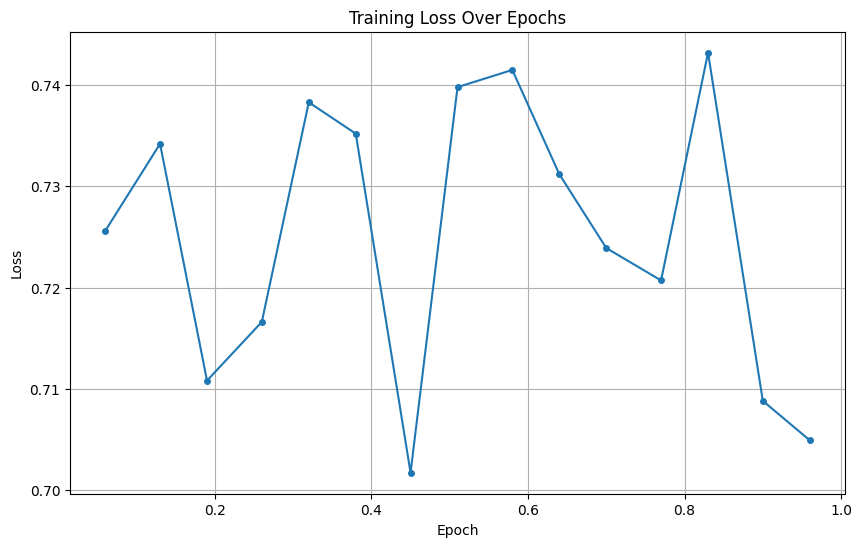

In [21]:
import re
import matplotlib.pyplot as plt
import json

log_file_path = '/content/drive/MyDrive/TCSS590/Llava/logs/train_log.txt'

losses = []
epochs = []

try:
    with open(log_file_path, 'r') as f:
        for line in f:
            # Regex to find dictionary-like structures containing 'loss' and 'epoch'
            match = re.search(r"{'loss': ([0-9.]+), 'learning_rate': [0-9.]+e?[+\-]?([0-9]+)?, 'epoch': ([0-9.]+)}", line)
            if match:
                loss = float(match.group(1))
                epoch = float(match.group(3))
                losses.append(loss)
                epochs.append(epoch)
except FileNotFoundError:
    print(f"Error: Log file not found at {log_file_path}")
except Exception as e:
    print(f"An error occurred while reading the log file: {e}")

if losses:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, losses, marker='o', linestyle='-', markersize=4)
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()
else:
    print("No loss data found in the log file to plot.")

In [24]:
# Check contents
!ls /content/llava-bench-wild/

answers_gpt4.jsonl  bing_chat_0629.jsonl  images	   README.md
bard_0718.jsonl     context.jsonl	  questions.jsonl


In [25]:
# Check images
!ls -lh /content/llava-bench-wild/images/ | head -5

total 9.4M
-rw-r--r-- 1 root root 1.1M Mar 17 19:44 001.jpg
-rw-r--r-- 1 root root 202K Mar 17 19:44 002.jpg
-rw-r--r-- 1 root root 448K Mar 17 19:44 003.jpg
-rw-r--r-- 1 root root 111K Mar 17 19:44 004.jpg


In [26]:
# Check questions file exists
!head -3 /content/llava-bench-wild/questions.jsonl

{"image": "001.jpg", "text": "What is the name of this famous sight in the photo?", "category": "conv", "question_id": 0}
{"image": "001.jpg", "text": "Describe this photo in detail.", "category": "detail", "question_id": 1}
{"image": "001.jpg", "text": "What are the possible reasons of the formation of this sight?", "category": "complex", "question_id": 2}


In [27]:
!mkdir -p /content/drive/MyDrive/TCSS590/Llava/PathB

In [29]:
!pip install -q shortuuid

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llava 1.2.2.post1 requires einops-exts==0.0.4, which is not installed.
llava 1.2.2.post1 requires markdown2[all], which is not installed.
llava 1.2.2.post1 requires accelerate==0.21.0, but you have accelerate 0.27.2 which is incompatible.
llava 1.2.2.post1 requires einops==0.6.1, but you have einops 0.8.2 which is incompatible.
llava 1.2.2.post1 requires gradio==4.16.0, but you have gradio 5.50.0 which is incompatible.
llava 1.2.2.post1 requires gradio_client==0.8.1, but you have gradio-client 1.14.0 which is incompatible.
llava 1.2.2.post1 requires httpx==0.24.0, but you have httpx 0.28.1 which is incompatible.
llava 1.2.2.post1 requires scikit-learn==1.2.2, but you have scikit-learn 1.6.1 which is incompatible.
llava 1.2.2.post1 requires sentencepiece==0.1.99, but you have sentencepiece 0.2.1 which is incompatib

In [30]:
# Generate answers on LLaVA-Bench-in-the-Wild
!python /content/LLaVA/llava/eval/model_vqa.py \
    --model-path /content/drive/MyDrive/TCSS590/Llava/checkpoints/llava-lora-sample \
    --model-base liuhaotian/llava-v1.5-7b \
    --question-file /content/llava-bench-wild/questions.jsonl \
    --image-folder /content/llava-bench-wild/images \
    --answers-file /content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_answers.jsonl \
    --temperature 0 \
    --conv-mode vicuna_v1

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-03-17 20:04:12.967974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773777852.991220   35456 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773777852.999259   35456 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773777853.020442   35456 computation_placer.cc:177] computation placer already registered. Please check lin

In [31]:
!ls -lh /content/llava-bench-wild/questions.jsonl
!ls -lh /content/llava-bench-wild/context.jsonl
!ls -lh /content/llava-bench-wild/answers_gpt4.jsonl
!ls -lh /content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_answers.jsonl

-rw-r--r-- 1 root root 8.1K Mar 17 19:44 /content/llava-bench-wild/questions.jsonl
-rw-r--r-- 1 root root 7.9K Mar 17 19:44 /content/llava-bench-wild/context.jsonl
-rw-r--r-- 1 root root 46K Mar 17 19:44 /content/llava-bench-wild/answers_gpt4.jsonl
-rw------- 1 root root 47K Mar 17 20:09 /content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_answers.jsonl


In [33]:
# Pin to old openai version that matches the script
!pip install -q openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 7.3 MB/s eta 0:00:00


In [35]:
# Fix the model name in the eval script
!sed -i 's/gpt-4-0314/gpt-4o-mini/g' /content/LLaVA/llava/eval/eval_gpt_review_bench.py

# Verify
!grep "model" /content/LLaVA/llava/eval/eval_gpt_review_bench.py | head -5

                model='gpt-4o-mini',


## LLaVA-Bench score

In [ ]:
import os


!python /content/LLaVA/llava/eval/eval_gpt_review_bench.py \
    --question   /content/llava-bench-wild/questions.jsonl \
    --context    /content/llava-bench-wild/context.jsonl \
    --rule       /content/LLaVA/llava/eval/table/rule.json \
    --answer-list /content/llava-bench-wild/answers_gpt4.jsonl \
                  /content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_answers.jsonl \
    --output     /content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_scores.jsonl

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60


In [38]:
import json

scores = []
with open('/content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_scores.jsonl') as f:
    for line in f:
        scores.append(json.loads(line))

# See the actual structure
print(f"Total entries: {len(scores)}")
print("\nFirst entry:")
print(json.dumps(scores[0], indent=2))

print("\nSecond entry:")
print(json.dumps(scores[1], indent=2))

Total entries: 60

First entry:
{
  "id": 1,
  "question_id": 0,
  "answer1_id": "TeyehNxHw5j8naXfEWaxWd",
  "answer2_id": "XJJyAe5GAVgJyKgnCF36Fd",
  "category": "llava_bench_conv",
  "content": "10 1\n\nAssistant 1 provided an accurate and relevant response by correctly identifying the famous sight as Diamond Head, which matches the context given in the question. The answer is straightforward and directly addresses the user's inquiry.\n\nOn the other hand, Assistant 2 incorrectly identified the sight as the Na Pali Coast on the island of Kaua'i, which is not relevant to the context of Diamond Head. This response is not only inaccurate but also misleading, as it refers to a completely different location in Hawaii. The lack of relevance and accuracy significantly lowers the quality of Assistant 2's response. \n\nOverall, Assistant 1's response is exemplary, while Assistant 2's response fails to meet the user's needs.",
  "tuple": [
    10.0,
    1.0
  ]
}

Second entry:
{
  "id": 2,
  

## Score Summary

In [39]:
import json
from collections import defaultdict

scores = []
with open('/content/drive/MyDrive/TCSS590/Llava/PathB/llava_bench_scores.jsonl') as f:
    for line in f:
        scores.append(json.loads(line))

# Extract scores from 'tuple' field
gpt4_scores = [s['tuple'][0] for s in scores]
your_scores  = [s['tuple'][1] for s in scores]

print(f"Total questions evaluated  : {len(scores)}")
print(f"GPT-4 avg score            : {sum(gpt4_scores)/len(gpt4_scores):.2f}")
print(f"Your model avg score       : {sum(your_scores)/len(your_scores):.2f}")
print(f"Relative score (yours/gpt4): {sum(your_scores)/sum(gpt4_scores)*100:.1f}%")

# Break down by category
category_scores = defaultdict(lambda: {'gpt4': [], 'yours': []})
for s in scores:
    category_scores[s['category']]['gpt4'].append(s['tuple'][0])
    category_scores[s['category']]['yours'].append(s['tuple'][1])

print("\nScores by category:")
print(f"{'Category':<25} {'GPT-4':>6} {'Yours':>6} {'Relative':>10}")
print("-" * 50)
for cat, cat_scores in sorted(category_scores.items()):
    gpt4_avg  = sum(cat_scores['gpt4'])/len(cat_scores['gpt4'])
    yours_avg = sum(cat_scores['yours'])/len(cat_scores['yours'])
    relative  = yours_avg/gpt4_avg*100
    print(f"{cat:<25} {gpt4_avg:>6.2f} {yours_avg:>6.2f} {relative:>9.1f}%")

Total questions evaluated  : 60
GPT-4 avg score            : 8.20
Your model avg score       : 5.70
Relative score (yours/gpt4): 69.5%

Scores by category:
Category                   GPT-4  Yours   Relative
--------------------------------------------------
llava_bench_complex         7.86   6.54      83.2%
llava_bench_conv            8.94   5.12      57.2%
llava_bench_detail          8.00   4.80      60.0%


In [40]:
import json

summary = {
    "total_questions": 60,
    "gpt4_avg": 8.20,
    "your_avg": 5.70,
    "relative_score_pct": 69.5,
    "by_category": {
        "llava_bench_complex": {"gpt4": 7.86, "yours": 6.54, "relative": 83.2},
        "llava_bench_conv":    {"gpt4": 8.94, "yours": 5.12, "relative": 57.2},
        "llava_bench_detail":  {"gpt4": 8.00, "yours": 4.80, "relative": 60.0}
    }
}

with open('/content/drive/MyDrive/TCSS590/Llava/PathB/benchmark_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Results saved to Drive!")

Results saved to Drive!
